# 🕵️‍♀️ Face Verification - Model Evaluation

### Library imports

In [1]:
%matplotlib inline

import os
import sys
import random
import yaml
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

sys.path.append(os.path.abspath(os.path.join('..')))

from src.model import SiameseNetwork

### Configuration and hardware setup

In [2]:
config_path = '../configs/baseline.yaml'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

MODEL_PATH = os.path.join('..', config['paths']['save_path'])
DATA_DIR = os.path.join('..', config['paths']['data_dir'])

device = torch.device("mps")

### Evaluation Engine & ROC Curve Logic

In [3]:
def evaluate_accuracy(model_path, data_dir, device, num_pairs=200):
    print("Loading model for evaluation...")
    model = SiameseNetwork(embedding_dim=128).to(device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
    except FileNotFoundError:
        print(f"[ERROR] Weights file not found at {model_path}.")
        return

    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    all_people = [p for p in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, p))]
    people_with_multiple_images = [p for p in all_people if len(os.listdir(os.path.join(data_dir, p))) >= 2]

    y_true = []
    distances = []

    print(f"Evaluating {num_pairs} random pairs (50% matching, 50% non-matching)...")

    with torch.no_grad():
        for i in range(num_pairs):
            is_positive_pair = (i % 2 == 0)

            if is_positive_pair and len(people_with_multiple_images) > 0:
                person = random.choice(people_with_multiple_images)
                person_dir = os.path.join(data_dir, person)
                img1_name, img2_name = random.sample(os.listdir(person_dir), 2)
                img1_path = os.path.join(person_dir, img1_name)
                img2_path = os.path.join(person_dir, img2_name)
                expected_label = 1
            else:
                person1, person2 = random.sample(all_people, 2)
                img1_name = random.choice(os.listdir(os.path.join(data_dir, person1)))
                img2_name = random.choice(os.listdir(os.path.join(data_dir, person2)))
                img1_path = os.path.join(data_dir, person1, img1_name)
                img2_path = os.path.join(data_dir, person2, img2_name)
                expected_label = 0

            try:
                img1 = transform(Image.open(img1_path).convert('RGB')).unsqueeze(0).to(device)
                img2 = transform(Image.open(img2_path).convert('RGB')).unsqueeze(0).to(device)
                
                emb1 = model(img1)
                emb2 = model(img2)
                
                dist = F.pairwise_distance(emb1, emb2).item()
                y_true.append(expected_label)
                distances.append(dist)
            except Exception:
                continue

    y_true = np.array(y_true)
    distances = np.array(distances)

    # Calculate ROC curve and optimal threshold
    fpr, tpr, roc_thresholds = roc_curve(y_true, -distances)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = -roc_thresholds[optimal_idx]

    print(f"\n[AI ANALYSIS] The dynamically calculated OPTIMAL threshold is: {optimal_threshold:.4f}")

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.scatter([fpr[optimal_idx]], [tpr[optimal_idx]], color='red', s=100, zorder=5, 
                label=f'Optimal Threshold ({optimal_threshold:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Security Leaks)')
    plt.ylabel('True Positive Rate (Correct Access)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Generate classification matrix and report
    y_pred = (distances < optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    report = classification_report(y_true, y_pred, target_names=['Different People', 'Same Person'])

    print("=======================================")
    print("         DETAILED EVALUATION REPORT     ")
    print("=======================================")
    print(report)
    print("---------------------------------------")
    print("CONFUSION MATRIX:")
    print(f" True Negatives (Correct Denied):  {tn}")
    print(f" False Positives (Security Leaks): {fp} <-- Lower is better!")
    print(f" False Negatives (False Alarms):  {fn}")
    print(f" True Positives (Correct Allowed): {tp}")
    print("=======================================\n")

### Execution Pipeline

Loading model for evaluation...
Evaluating 300 random pairs (50% matching, 50% non-matching)...

[AI ANALYSIS] The dynamically calculated OPTIMAL threshold is: 0.5594


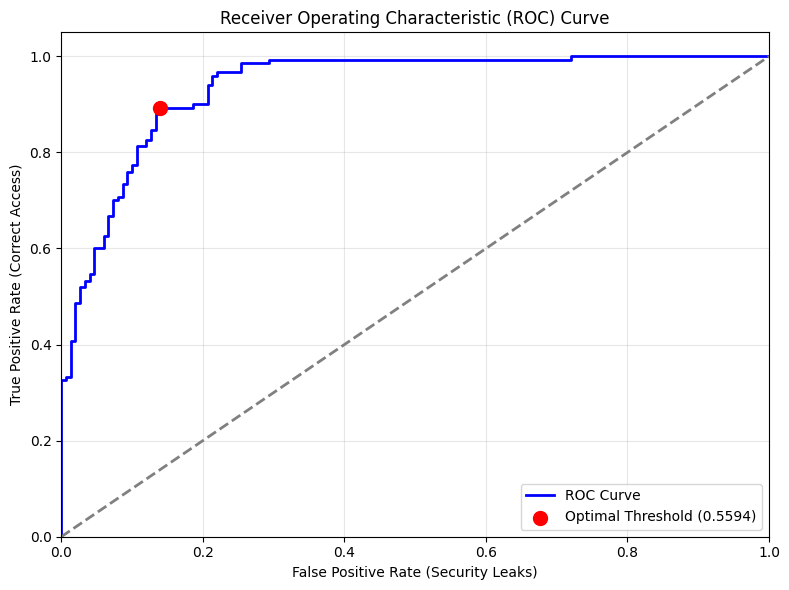

         DETAILED EVALUATION REPORT     
                  precision    recall  f1-score   support

Different People       0.88      0.86      0.87       150
     Same Person       0.86      0.89      0.88       150

        accuracy                           0.87       300
       macro avg       0.87      0.87      0.87       300
    weighted avg       0.87      0.87      0.87       300

---------------------------------------
CONFUSION MATRIX:
 True Negatives (Correct Denied):  129
 False Positives (Security Leaks): 21 <-- Lower is better!
 False Negatives (False Alarms):  17
 True Positives (Correct Allowed): 133



In [4]:
evaluate_accuracy(
    model_path=MODEL_PATH, 
    data_dir=DATA_DIR, 
    device=device, 
    num_pairs=300
)